In [1]:
import pathlib
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
# ignore threadpoolctl warnings from pymc
import warnings
warnings.filterwarnings('ignore', module="threadpoolctl")

In [2]:
train_folder = pathlib.Path("..") / "assets" / "CBM_dataset" / "train"

train_dataframes = {
    csv_file.stem: pd.read_csv(csv_file)
    for csv_file in train_folder.glob("*.csv")
}

list(train_dataframes.keys())

['complete_df_train']

In [3]:
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)
for name, df in train_dataframes.items():
	print(f"{name}:")
	print(df.head())
	print("-" * 120)

complete_df_train:
   machine_id  time  degra_level_observed  region  route      speed      load  brake_temperature  vibration_level  rul  segment_id
0           1     0              0.000000       1      1  33.752256  0.718434           0.000000         0.047835   88           1
1           1     1              0.042079       1      0  90.884743  0.637161           3.031550         0.000000   87           1
2           1     2              0.000000       1      1  29.915994  0.539073           0.000000         0.142555   86           1
3           1     3              0.000000       1      1  33.888960  0.630980           0.000000         0.000000   85           1
4           1     4              0.000000       1      1  32.337547  0.538448           7.716752         0.059371   84           1
------------------------------------------------------------------------------------------------------------------------


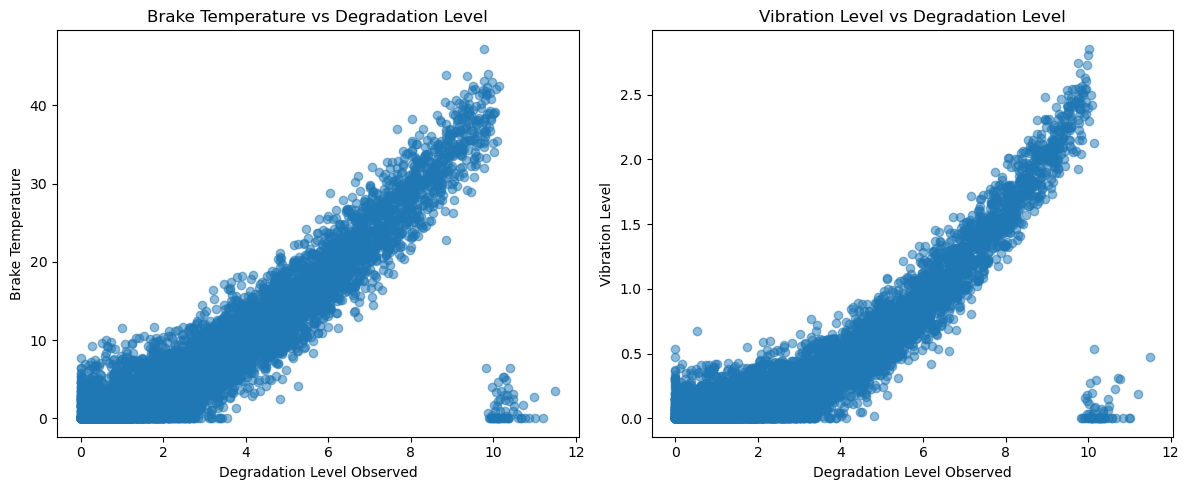

In [4]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df['degra_level_observed'], df['brake_temperature'], alpha=0.5)
plt.xlabel('Degradation Level Observed')
plt.ylabel('Brake Temperature')
plt.title('Brake Temperature vs Degradation Level')

plt.subplot(1, 2, 2)
plt.scatter(df['degra_level_observed'], df['vibration_level'], alpha=0.5)
plt.xlabel('Degradation Level Observed')
plt.ylabel('Vibration Level')
plt.title('Vibration Level vs Degradation Level')

plt.tight_layout()
plt.show()

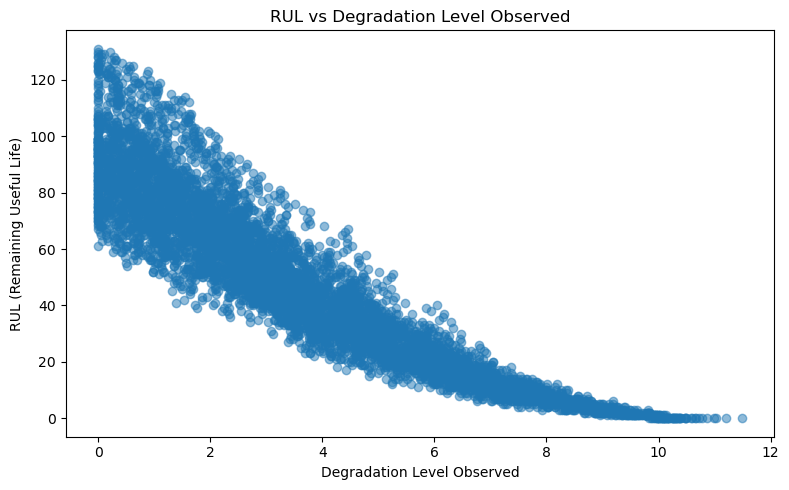

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(df['degra_level_observed'], df['rul'], alpha=0.5)
plt.xlabel('Degradation Level Observed')
plt.ylabel('RUL (Remaining Useful Life)')
plt.title('RUL vs Degradation Level Observed')
plt.tight_layout()
plt.show()

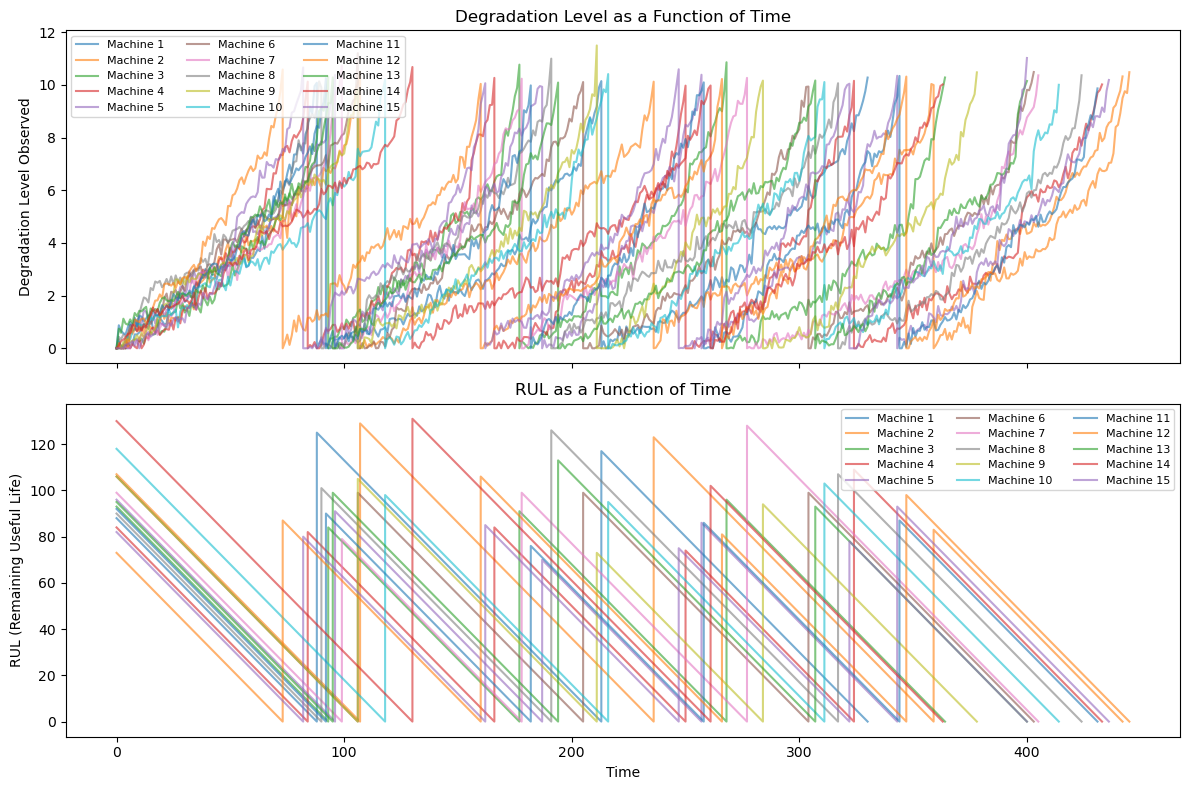

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for machine_id, group in df.groupby('machine_id'):
    axes[0].plot(group['time'], group['degra_level_observed'], alpha=0.6, label=f'Machine {machine_id}')
    axes[1].plot(group['time'], group['rul'], alpha=0.6, label=f'Machine {machine_id}')

axes[0].set_ylabel('Degradation Level Observed')
axes[0].set_title('Degradation Level as a Function of Time')
axes[0].legend(loc='upper left', fontsize=8, ncol=3)

axes[1].set_ylabel('RUL (Remaining Useful Life)')
axes[1].set_title('RUL as a Function of Time')
axes[1].set_xlabel('Time')
axes[1].legend(loc='upper right', fontsize=8, ncol=3)

plt.tight_layout()
plt.show()

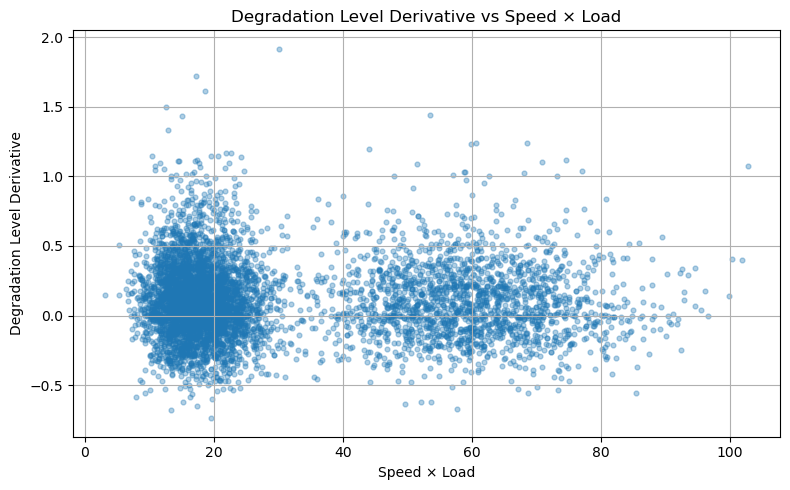

In [20]:
plot_df = df.sort_values(["machine_id", "time"]).copy()
plot_df["degra_derivative"] = (
    plot_df.groupby("machine_id")["degra_level_observed"].diff()
    / plot_df.groupby("machine_id")["time"].diff()
).fillna(0.0)

x = plot_df["speed"] * plot_df["load"]
y = plot_df["degra_derivative"]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.35, s=12)
plt.xlabel("Speed × Load")
plt.ylabel("Degradation Level Derivative")
plt.title("Degradation Level Derivative vs Speed × Load")
plt.tight_layout()
plt.grid()
plt.show()

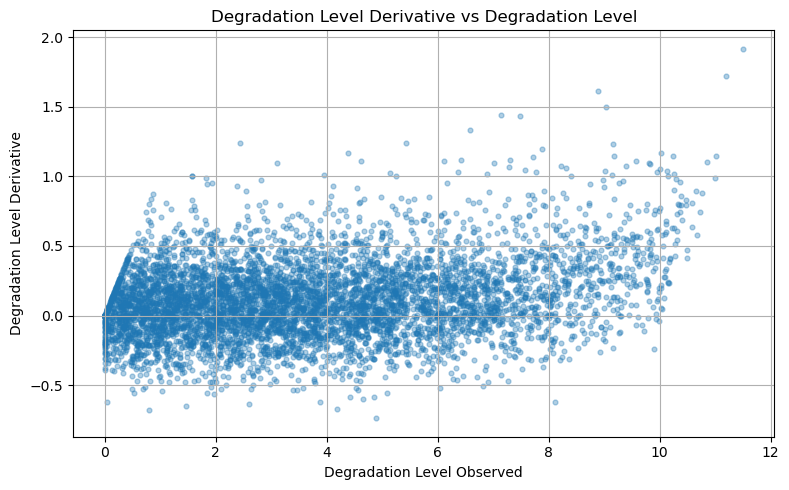

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(plot_df["degra_level_observed"], plot_df["degra_derivative"], alpha=0.35, s=12)
plt.xlabel("Degradation Level Observed")
plt.ylabel("Degradation Level Derivative")
plt.title("Degradation Level Derivative vs Degradation Level")
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
sorted(df['region'].unique())

[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

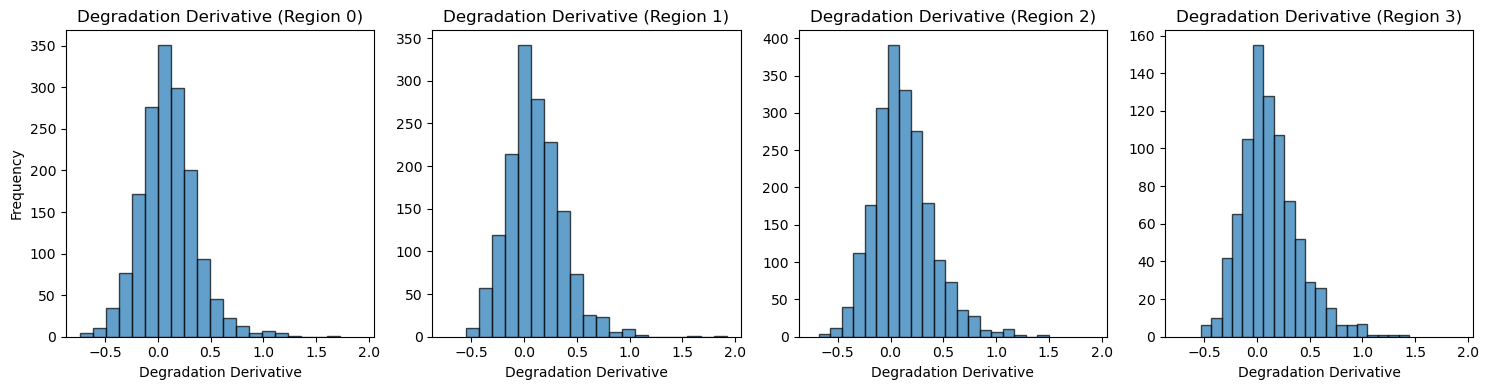

In [33]:
fig, axes = plt.subplots(1, len(df['region'].unique()), figsize=(15, 4), sharex=True)

for region in sorted(df['region'].unique()):
    region_data = plot_df[plot_df['region'] == region]['degra_derivative']
    idx = list(sorted(df['region'].unique())).index(region)
    region_data = region_data[np.isfinite(region_data)]
    axes[idx].hist(region_data, bins=20, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Degradation Derivative (Region {region})')
    axes[idx].set_xlabel('Degradation Derivative')
    if idx == 0:
        axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

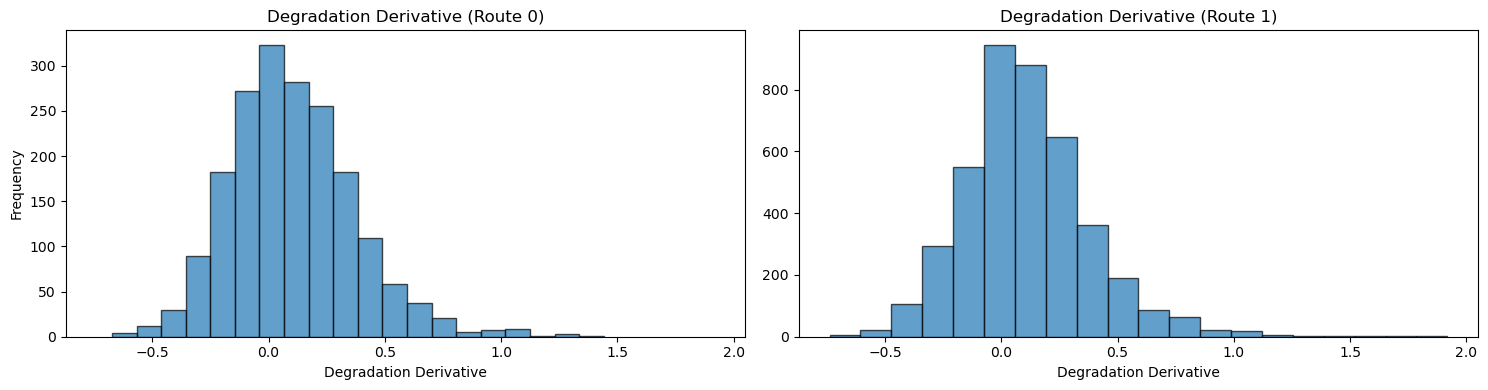

In [34]:
fig, axes = plt.subplots(1, len(df['route'].unique()), figsize=(15, 4), sharex=True)

for route in sorted(df['route'].unique()):
    route_data = plot_df[plot_df['route'] == route]['degra_derivative']
    idx = list(sorted(df['route'].unique())).index(route)
    route_data = route_data[np.isfinite(route_data)]
    axes[idx].hist(route_data, bins=20, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Degradation Derivative (Route {route})')
    axes[idx].set_xlabel('Degradation Derivative')
    if idx == 0:
        axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()